# Week 3: Nemotron Nano 4B Experiments
**Model:** `nemotron-3-nano:4b` via Ollama (local laptop: RTX 4060 8 GB)  
**Dataset:** `data/personas_sample_500.csv` (balanced 500-row test set)  
**Experiments:**
- Zero-shot classification (no examples given)
- Few-shot classification (5 labeled examples given)

**Baselines to beat (from Week 1):**
- Random Forest: Accuracy 83.70% · Macro F1 0.8366 · AUC-ROC 0.9198
- XGBoost:       Accuracy 76.01% · Macro F1 0.7598 · AUC-ROC 0.8307

# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import requests
import time
import re
import os

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

print("Imports OK")

Imports OK


# 2. Configuration

In [2]:
OLLAMA_URL  = "http://localhost:11434/v1/chat/completions"
MODEL_NAME  = "nemotron-3-nano:4b"  # real Nano 4B model
SAMPLE_PATH = "../data/personas_sample_500.csv"
RESULTS_DIR = "../results"

# Week 1 baseline results for comparison
BASELINES = {
    "Random Forest": {"accuracy": 0.8370, "macro_f1": 0.8366, "auc_roc": 0.9198, "ms_per_row": 0.007},
    "XGBoost":       {"accuracy": 0.7601, "macro_f1": 0.7598, "auc_roc": 0.8307, "ms_per_row": 0.001},
}

print(f"Model: {MODEL_NAME}")
print(f"Sample: {SAMPLE_PATH}")

Model: nemotron-3-nano:4b
Sample: ../data/personas_sample_500.csv


## 3. Load and Verify Sample

In [3]:
sample = pd.read_csv(SAMPLE_PATH)

# Filter uninformative occupations
sample = sample[
    ~sample["occupation"].str.lower().str.strip().isin([
        "no occupation", "not in workforce", "not_in_workforce", ""
    ])
].reset_index(drop=True)

print(f"Sample size: {len(sample)} rows")
print(f"Label balance:")
print(sample["label_name"].value_counts())
print()
sample.head(3)

Sample size: 500 rows
Label balance:
label_name
not_college    276
college        224
Name: count, dtype: int64



,age,sex,marital_status,occupation,state,label,label_name,education_level
0,50,Male,married_present,police_officer,PA,1,college,bachelors
1,22,Male,never_married,waiter_or_waitress,KY,0,not_college,high_school
2,53,Female,married_present,community_or_social_service_specialist,CO,1,college,graduate


## 4. Helper Functions

In [4]:
SYSTEM_PROMPT = """You are an education level classifier. Given a person's demographic information,
predict whether they are college-educated (have a bachelor's degree or higher) or not.
Think step by step, then respond with ONLY one of these two labels on the final line: college or not_college."""


def serialize_row(row):
    return (
        f"A {int(row['age'])}-year-old {str(row['sex']).lower().strip()}, "
        f"{str(row['marital_status']).replace('_', ' ').strip()}, "
        f"working as a {str(row['occupation']).replace('_', ' ').strip()}. "
        f"Located in {str(row['state']).strip()}."
    )


def build_zero_shot_prompt(row):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": (
            f"Classify this person's education level:\n\n"
            f"{serialize_row(row)}\n\n"
            f"Answer with college or not_college only."
        )}
    ]


def build_few_shot_prompt(row, examples):
    example_text = ""
    for ex in examples:
        example_text += f"Person: {serialize_row(ex)}\nLabel: {ex['label_name']}\n\n"
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": (
            f"Here are some labeled examples:\n\n{example_text}"
            f"Now classify this person:\n\n"
            f"{serialize_row(row)}\n\n"
            f"Answer with college or not_college only."
        )}
    ]


def parse_response(content):
    think_match = re.search(r"<think>(.*?)</think>", content, re.DOTALL)
    trace = think_match.group(1).strip() if think_match else ""
    label_match = re.search(r"\b(not_college|college)\b", content, re.IGNORECASE)
    label = label_match.group(1).lower() if label_match else "UNKNOWN"
    return label, trace


def classify_row(messages, timeout=120):
    payload = {
        "model": MODEL_NAME,
        "messages": messages,
        "max_tokens": 1024,
        "temperature": 0.1,
        "stream": False,
        "options": {"num_ctx": 4096},
    }
    start = time.time()
    try:
        response = requests.post(OLLAMA_URL, json=payload, timeout=timeout).json()
        elapsed = time.time() - start
        content = response["choices"][0]["message"]["content"]
        tokens  = response.get("usage", {}).get("completion_tokens", 0)
        label, trace = parse_response(content)
    except Exception as e:
        elapsed = time.time() - start
        label, trace, tokens, content = "ERROR", str(e), 0, str(e)
    return {
        "label":   label,
        "trace":   trace,
        "raw":     content,
        "time_ms": round(elapsed * 1000),
        "tokens":  tokens,
    }


print("All helper functions defined.")

All helper functions defined.


## 5. Evaluation Helper

In [5]:
def evaluate_llm_results(results_df, run_name):
    """
    Compute metrics for one LLM run.
    results_df must have columns: true_label, pred_label, time_ms, tokens
    """
    label_map = {"college": 1, "not_college": 0}

    # Filter out UNKNOWN predictions
    valid = results_df[results_df["pred_label"].isin(["college", "not_college"])].copy()
    unknown_count = len(results_df) - len(valid)

    y_true = valid["true_label"].map(label_map)
    y_pred = valid["pred_label"].map(label_map)

    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average="macro")
    auc  = roc_auc_score(y_true, y_pred)
    avg_ms = results_df["time_ms"].mean()
    avg_tokens = results_df["tokens"].mean()

    print(f"\n{'='*50}")
    print(f"  {run_name}")
    print(f"{'='*50}")
    print(f"  Rows evaluated:  {len(valid)} / {len(results_df)}")
    print(f"  Unknown:         {unknown_count}")
    print(f"  Accuracy:        {acc:.4f}")
    print(f"  Macro F1:        {f1:.4f}")
    print(f"  AUC-ROC:         {auc:.4f}")
    print(f"  Avg time/row:    {avg_ms:.0f}ms")
    print(f"  Avg tokens:      {avg_tokens:.0f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["not_college", "college"]))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=["not_college", "college"]).plot(ax=ax, colorbar=False)
    ax.set_title(run_name)
    plt.tight_layout()
    fname = f"{RESULTS_DIR}/cm_{run_name.replace(' ', '_').lower()}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")

    return {
        "model":        run_name,
        "accuracy":     round(acc, 4),
        "macro_f1":     round(f1, 4),
        "auc_roc":      round(auc, 4),
        "ms_per_row":   round(avg_ms, 1),
        "avg_tokens":   round(avg_tokens, 1),
        "unknown":      unknown_count,
        "n_samples":    len(valid),
        "week":         3,
        "device":       "local-rtx4060",
        "dataset":      "nvidia/Nemotron-Personas-USA",
    }

all_results = []
print("evaluate_llm_results() defined.")

evaluate_llm_results() defined.


## 6. Few-shot Example Pool
Sample 5 examples from the dataset to use in few-shot prompts.
We pick balanced examples — some college, some not_college — with clear occupation signals.

In [6]:
# Sample 5 few-shot examples we fixed random_state for reproducibility
# 3 college + 2 not_college for slight emphasis on the minority class
fs_college = sample[sample["label_name"] == "college"].sample(3, random_state=1)
fs_not     = sample[sample["label_name"] == "not_college"].sample(2, random_state=1)
few_shot_examples = pd.concat([fs_college, fs_not]).sample(frac=1, random_state=1).to_dict("records")

print("Few-shot examples:")
for ex in few_shot_examples:
    print(f"  {serialize_row(ex)} → {ex['label_name']}")

Few-shot examples:
  A 58-year-old female, divorced, working as a lodging manager. Located in AR. → college
  A 40-year-old male, divorced, working as a driver sales worker or truck driver. Located in IL. → college
  A 27-year-old female, never married, working as a packer or packager. Located in LA. → not_college
  A 37-year-old female, never married, working as a software developer. Located in OK. → college
  A 23-year-old male, never married, working as a statistician. Located in TX. → not_college


## 7. Experiment A: Zero-shot (500 rows)
No examples given. Nemotron classifies from the description alone.

> **Expected time:** ~20-30 minutes. Run and come back.

In [7]:
print(f"Starting zero-shot experiment on {len(sample)} rows...")
print(f"Estimated time: ~{len(sample) * 4 / 60:.0f} minutes\n")

zs_results = []
t_start = time.time()

for i, row in sample.iterrows():
    messages = build_zero_shot_prompt(row.to_dict())
    result   = classify_row(messages)

    zs_results.append({
        "row_id":     i,
        "input":      serialize_row(row.to_dict()),
        "true_label": row["label_name"],
        "pred_label": result["label"],
        "correct":    result["label"] == row["label_name"],
        "time_ms":    result["time_ms"],
        "tokens":     result["tokens"],
        "trace":      result["trace"],
        "raw":        result["raw"],
    })

    # Progress every 50 rows
    if (i + 1) % 50 == 0:
        elapsed  = time.time() - t_start
        done     = i + 1
        remaining = (elapsed / done) * (len(sample) - done)
        print(f"  Row {done:3d}/{len(sample)} | "
              f"Elapsed: {elapsed/60:.1f}min | "
              f"Remaining: ~{remaining/60:.1f}min")

zs_df = pd.DataFrame(zs_results)
os.makedirs(RESULTS_DIR, exist_ok=True)
zs_df.to_csv(f"{RESULTS_DIR}/week3_zeroshot_raw.csv", index=False)
print(f"\nDone! Saved raw results: results/week3_zeroshot_raw.csv")
print(f"Total time: {(time.time()-t_start)/60:.1f} minutes")

Starting zero-shot experiment on 500 rows...
Estimated time: ~33 minutes

  Row  50/500 | Elapsed: 3.0min | Remaining: ~27.3min
  Row 100/500 | Elapsed: 6.1min | Remaining: ~24.6min
  Row 150/500 | Elapsed: 9.1min | Remaining: ~21.3min
  Row 200/500 | Elapsed: 12.1min | Remaining: ~18.2min
  Row 250/500 | Elapsed: 15.1min | Remaining: ~15.1min
  Row 300/500 | Elapsed: 18.1min | Remaining: ~12.1min
  Row 350/500 | Elapsed: 21.2min | Remaining: ~9.1min
  Row 400/500 | Elapsed: 24.2min | Remaining: ~6.1min
  Row 450/500 | Elapsed: 27.2min | Remaining: ~3.0min
  Row 500/500 | Elapsed: 30.2min | Remaining: ~0.0min

Done! Saved raw results: results/week3_zeroshot_raw.csv
Total time: 30.2 minutes


## 8. Zero-shot Results


  Nano 4B zero-shot
  Rows evaluated:  500 / 500
  Unknown:         0
  Accuracy:        0.6000
  Macro F1:        0.5781
  AUC-ROC:         0.5826
  Avg time/row:    3620ms
  Avg tokens:      94

              precision    recall  f1-score   support

 not_college       0.61      0.75      0.67       276
     college       0.57      0.42      0.48       224

    accuracy                           0.60       500
   macro avg       0.59      0.58      0.58       500
weighted avg       0.60      0.60      0.59       500



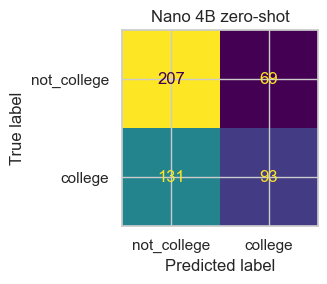

Saved: ../results/cm_nano_4b_zero-shot.png


In [8]:
zs_metrics = evaluate_llm_results(zs_df, "Nano 4B zero-shot")
all_results.append(zs_metrics)

## 9. Experiment B: Few-shot (500 rows)
5 labeled examples shown before each classification.

> **Expected time:** ~25-35 minutes (slightly longer than zero-shot due to longer prompts).

In [9]:
print(f"Starting few-shot experiment on {len(sample)} rows...")
print(f"Estimated time: ~{len(sample) * 4.5 / 60:.0f} minutes\n")

fs_results = []
t_start = time.time()

for i, row in sample.iterrows():
    messages = build_few_shot_prompt(row.to_dict(), few_shot_examples)
    result   = classify_row(messages)

    fs_results.append({
        "row_id":     i,
        "input":      serialize_row(row.to_dict()),
        "true_label": row["label_name"],
        "pred_label": result["label"],
        "correct":    result["label"] == row["label_name"],
        "time_ms":    result["time_ms"],
        "tokens":     result["tokens"],
        "trace":      result["trace"],
        "raw":        result["raw"],
    })

    # Progress every 50 rows
    if (i + 1) % 50 == 0:
        elapsed   = time.time() - t_start
        done      = i + 1
        remaining = (elapsed / done) * (len(sample) - done)
        print(f"  Row {done:3d}/{len(sample)} | "
              f"Elapsed: {elapsed/60:.1f}min | "
              f"Remaining: ~{remaining/60:.1f}min")

fs_df = pd.DataFrame(fs_results)
fs_df.to_csv(f"{RESULTS_DIR}/week3_fewshot_raw.csv", index=False)
print(f"\nDone! Saved raw results: results/week3_fewshot_raw.csv")
print(f"Total time: {(time.time()-t_start)/60:.1f} minutes")

Starting few-shot experiment on 500 rows...
Estimated time: ~38 minutes

  Row  50/500 | Elapsed: 6.2min | Remaining: ~55.9min
  Row 100/500 | Elapsed: 12.2min | Remaining: ~48.8min
  Row 150/500 | Elapsed: 17.9min | Remaining: ~41.7min
  Row 200/500 | Elapsed: 23.7min | Remaining: ~35.6min
  Row 250/500 | Elapsed: 29.5min | Remaining: ~29.5min
  Row 300/500 | Elapsed: 35.7min | Remaining: ~23.8min
  Row 350/500 | Elapsed: 41.6min | Remaining: ~17.8min
  Row 400/500 | Elapsed: 47.6min | Remaining: ~11.9min
  Row 450/500 | Elapsed: 53.4min | Remaining: ~5.9min
  Row 500/500 | Elapsed: 59.5min | Remaining: ~0.0min

Done! Saved raw results: results/week3_fewshot_raw.csv
Total time: 59.5 minutes


## 10. Few-shot Results


  Nano 4B few-shot
  Rows evaluated:  495 / 500
  Unknown:         5
  Accuracy:        0.6485
  Macro F1:        0.6480
  AUC-ROC:         0.6594
  Avg time/row:    7145ms
  Avg tokens:      341

              precision    recall  f1-score   support

 not_college       0.74      0.55      0.63       273
     college       0.58      0.77      0.66       222

    accuracy                           0.65       495
   macro avg       0.66      0.66      0.65       495
weighted avg       0.67      0.65      0.65       495



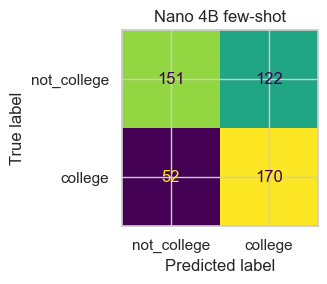

Saved: ../results/cm_nano_4b_few-shot.png


In [10]:
fs_metrics = evaluate_llm_results(fs_df, "Nano 4B few-shot")
all_results.append(fs_metrics)

## 11. Comparison: Nano 4B vs Week 1 Baselines

In [11]:
# Build full comparison table including Week 1 baselines
baseline_rows = [
    {"model": "Random Forest", "accuracy": 0.8370, "macro_f1": 0.8366,
     "auc_roc": 0.9198, "ms_per_row": 0.007, "week": 1, "device": "local-cpu"},
    {"model": "XGBoost",       "accuracy": 0.7601, "macro_f1": 0.7598,
     "auc_roc": 0.8307, "ms_per_row": 0.001, "week": 1, "device": "local-cpu"},
]

comparison_df = pd.DataFrame(baseline_rows + all_results)
print("=== FULL COMPARISON: Week 1 Baselines vs Nano 4B ===")
print(comparison_df[["model", "accuracy", "macro_f1", "auc_roc", "ms_per_row"]].to_string(index=False))

=== FULL COMPARISON: Week 1 Baselines vs Nano 4B ===
            model  accuracy  macro_f1  auc_roc  ms_per_row
    Random Forest    0.8370    0.8366   0.9198       0.007
          XGBoost    0.7601    0.7598   0.8307       0.001
Nano 4B zero-shot    0.6000    0.5781   0.5826    3619.900
 Nano 4B few-shot    0.6485    0.6480   0.6594    7144.700


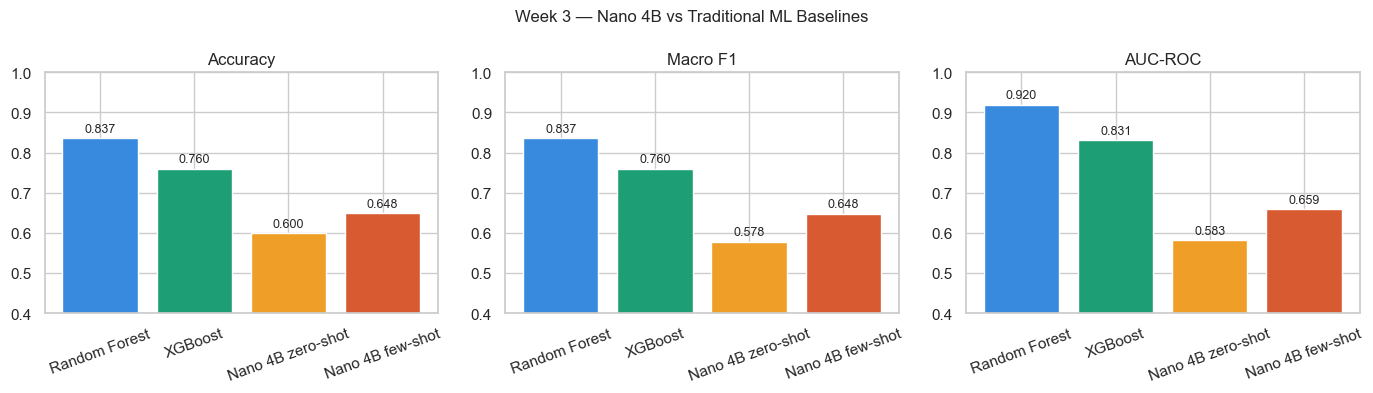

Saved: results/week3_comparison.png


In [12]:
# Side-by-side bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["accuracy", "macro_f1", "auc_roc"]
titles  = ["Accuracy", "Macro F1", "AUC-ROC"]
colors  = ["#378ADD", "#1D9E75", "#EF9F27", "#D85A30"]

for ax, metric, title in zip(axes, metrics, titles):
    vals  = comparison_df[metric].values
    names = comparison_df["model"].values
    bars  = ax.bar(names, vals, color=colors[:len(vals)])
    ax.set_title(title)
    ax.set_ylim(0.4, 1.0)
    ax.tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Week 3 — Nano 4B vs Traditional ML Baselines", fontsize=12)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week3_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week3_comparison.png")

## 12. Label Noise Analysis
Identify rows where Nemotron's prediction likely reflects real-world knowledge
but conflicts with the synthetic dataset label.

In [13]:
# High-confidence college occupations that were labeled not_college in the dataset
COLLEGE_OCCUPATIONS = [
    "software developer", "engineer", "doctor", "physician", "surgeon",
    "lawyer", "attorney", "architect", "nurse", "registered nurse",
    "accountant", "auditor", "financial manager", "occupational therapist",
    "database administrator", "teacher"
]

# Find rows where model predicted college but label is not_college
# AND the occupation is in our known college list
potential_noise = zs_df[
    (zs_df["true_label"] == "not_college") &
    (zs_df["pred_label"] == "college") &
    (zs_df["input"].str.lower().str.contains("|".join(COLLEGE_OCCUPATIONS)))
].copy()

print(f"Potential label noise rows (model says college, dataset says not_college):")
print(f"Count: {len(potential_noise)}")
print()
for _, row in potential_noise.head(5).iterrows():
    print(f"Input: {row['input']}")
    print(f"True: {row['true_label']} | Predicted: {row['pred_label']}")
    print()


# Adjusted accuracy excluding likely label noise rows
noise_ids = potential_noise["row_id"].values

zs_clean = zs_df[~zs_df["row_id"].isin(noise_ids)].copy()
clean_correct = (zs_clean["pred_label"] == zs_clean["true_label"]).mean()
print(f"Zero-shot accuracy (all rows):          {zs_df['correct'].mean():.4f}")
print(f"Zero-shot accuracy (excluding noise):   {clean_correct:.4f}")
print(f"Noise rows removed: {len(noise_ids)}")
print(f"Clean rows evaluated: {len(zs_clean)}")


fs_clean = fs_df[~fs_df["row_id"].isin(noise_ids)].copy()
fs_clean_correct = (fs_clean["pred_label"] == fs_clean["true_label"]).mean()
print(f"Few-shot accuracy (all rows):          {fs_df['correct'].mean():.4f}")
print(f"Few-shot accuracy (excluding noise):   {fs_clean_correct:.4f}")
print(f"Clean rows evaluated: {len(fs_clean)}")

Potential label noise rows (model says college, dataset says not_college):
Count: 19

Input: A 51-year-old female, never married, working as a software developer. Located in CA.
True: not_college | Predicted: college

Input: A 50-year-old female, married present, working as a engineer. Located in NE.
True: not_college | Predicted: college

Input: A 20-year-old male, never married, working as a architectural or engineering manager. Located in NV.
True: not_college | Predicted: college

Input: A 41-year-old male, married present, working as a lawyer. Located in TX.
True: not_college | Predicted: college

Input: A 28-year-old female, married present, working as a postsecondary teacher. Located in CA.
True: not_college | Predicted: college

Zero-shot accuracy (all rows):          0.6000
Zero-shot accuracy (excluding noise):   0.6237
Noise rows removed: 19
Clean rows evaluated: 481
Few-shot accuracy (all rows):          0.6420
Few-shot accuracy (excluding noise):   0.6653
Clean rows evaluat

## 13. Best Reasoning Traces
Save the best examples for the fellowship report.

In [14]:
# Find rows with non-empty reasoning traces
traces_df = zs_df[zs_df["trace"].str.len() > 10].copy()
print(f"Rows with reasoning traces: {len(traces_df)} / {len(zs_df)}")

if len(traces_df) > 0:
    print("\n=== CORRECT predictions with reasoning ===")
    correct_traces = traces_df[traces_df["correct"] == True].head(3)
    for _, row in correct_traces.iterrows():
        print(f"Input:     {row['input']}")
        print(f"Label:     {row['true_label']}")
        print(f"Reasoning: {row['trace'][:200]}...")
        print()

    print("\n=== WRONG predictions with reasoning ===")
    wrong_traces = traces_df[traces_df["correct"] == False].head(3)
    for _, row in wrong_traces.iterrows():
        print(f"Input:     {row['input']}")
        print(f"True: {row['true_label']} | Predicted: {row['pred_label']}")
        print(f"Reasoning: {row['trace'][:200]}...")
        print()
else:
    print("No reasoning traces found — Nano 4B may not be outputting think tags.")
    print("This is expected if thinking mode is not enabled.")
    print("Full reasoning traces will be available on the 30B model in Week 4.")

Rows with reasoning traces: 0 / 500
No reasoning traces found — Nano 4B may not be outputting think tags.
This is expected if thinking mode is not enabled.
Full reasoning traces will be available on the 30B model in Week 4.


## 14. Save All Results to metrics.csv

In [15]:
# Load existing metrics and append Week 3 results
metrics_path = f"{RESULTS_DIR}/metrics.csv"

try:
    existing = pd.read_csv(metrics_path)
    # Remove any previous Week 3 entries to avoid duplicates
    existing = existing[existing["week"] != 3]
    week3_df = pd.DataFrame(all_results)
    updated  = pd.concat([existing, week3_df], ignore_index=True)
except FileNotFoundError:
    updated = pd.DataFrame(all_results)

updated.to_csv(metrics_path, index=False)
print(f"Saved: {metrics_path}")
print()
print(updated[["model", "accuracy", "macro_f1", "auc_roc", "ms_per_row", "week"]].to_string(index=False))

Saved: ../results/metrics.csv

                    model  accuracy  macro_f1  auc_roc  ms_per_row  week
Random Forest (100 trees)    0.7709    0.7701   0.8556       0.011     1
                  XGBoost    0.7150    0.7149   0.7812       0.001     1
        Nano 4B zero-shot    0.6000    0.5781   0.5826    3619.900     3
         Nano 4B few-shot    0.6485    0.6480   0.6594    7144.700     3


## 15. K Means


Clean sample: 500 rows
Remaining no_occupation: 0
Label balance:
label_name
not_college    276
college        224
Name: count, dtype: int64


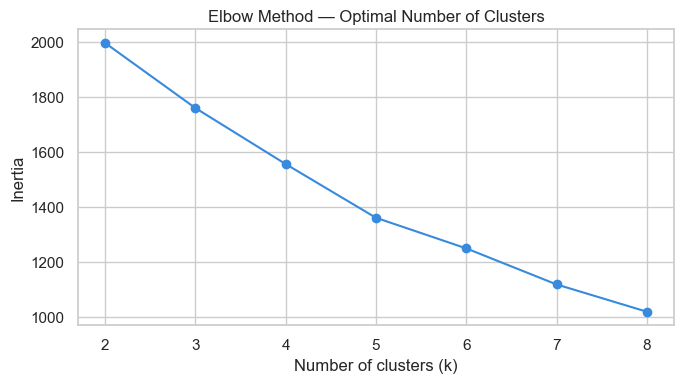

Saved: results/kmeans_elbow.png
Look at the elbow plot — pick k where the curve bends most sharply.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Reload saved results if kernel was restarted ──────────────────────
if 'sample' not in dir() or sample is None:
    sample = pd.read_csv("../data/personas_sample_500.csv")
    print(f'Reloaded sample: {len(sample)} rows')

if 'zs_df' not in dir() or zs_df is None:
    zs_df = pd.read_csv('../results/week3_zeroshot_raw.csv')
    print(f'Reloaded zero-shot results: {len(zs_df)} rows')

if 'fs_df' not in dir() or fs_df is None:
    fs_df = pd.read_csv('../results/week3_fewshot_raw.csv')
    print(f'Reloaded few-shot results: {len(fs_df)} rows')

# ── Broader filter for bad occupation rows ────────────────────────────
sample = sample[
    ~sample["occupation"].str.lower().str.strip().str.replace("_", " ").isin([
        "no occupation", "not in workforce", ""
    ]) &
    (sample["occupation"].str.strip() != "") &
    (sample["occupation"].notna())
].reset_index(drop=True)

print(f"\nClean sample: {len(sample)} rows")
print(f"Remaining no_occupation: {(sample['occupation'].str.lower().str.strip().str.replace('_', ' ') == 'no occupation').sum()}")
print(f"Label balance:")
print(sample["label_name"].value_counts())

# ── Encode features for clustering ───────────────────────────────────
cluster_features = ['age', 'sex', 'marital_status', 'occupation', 'state']
X_cluster = sample[cluster_features].copy()

le_dict = {}
for col in ['sex', 'marital_status', 'occupation', 'state']:
    le = LabelEncoder()
    X_cluster[col] = le.fit_transform(X_cluster[col].astype(str))
    le_dict[col] = le

# Scale so age doesn't dominate
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# ── Elbow method to find optimal k ───────────────────────────────────
inertias = []
k_range  = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker='o', color='#378ADD')
ax.set_title('Elbow Method — Optimal Number of Clusters')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig('../results/kmeans_elbow.png', dpi=150)
plt.show()
print('Saved: results/kmeans_elbow.png')
print('Look at the elbow plot — pick k where the curve bends most sharply.')


In [17]:
print(f"Remaining no_occupation rows: {(sample['occupation'].str.lower().str.strip() == 'no_occupation').sum()}")
print(f"Remaining not_in_workforce rows: {(sample['occupation'].str.lower().str.strip() == 'not_in_workforce').sum()}")
print(f"Total sample rows: {len(sample)}")

Remaining no_occupation rows: 0
Remaining not_in_workforce rows: 0
Total sample rows: 500



── Cluster 0 ──
  Size:              111 rows
  Zero-shot accuracy: 66.7%
  Few-shot accuracy:  64.9%
  College rate:      40.5%
  Avg age:           43.9
  Top occupations:   janitor_or_building_cleaner, driver_sales_worker_or_truck_driver, sales_representative_wholesale_or_manufacturing

── Cluster 1 ──
  Size:              126 rows
  Zero-shot accuracy: 61.9%
  Few-shot accuracy:  65.1%
  College rate:      39.7%
  Avg age:           40.2
  Top occupations:   manager, software_developer, police_officer

── Cluster 2 ──
  Size:              158 rows
  Zero-shot accuracy: 59.5%
  Few-shot accuracy:  66.5%
  College rate:      51.9%
  Avg age:           48.0
  Top occupations:   elementary_or_middle_school_teacher, customer_service_representative, accountant_or_auditor

── Cluster 3 ──
  Size:              105 rows
  Zero-shot accuracy: 51.4%
  Few-shot accuracy:  59.0%
  College rate:      44.8%
  Avg age:           39.1
  Top occupations:   cashier, laundry_or_dry_cleaning_worker, s

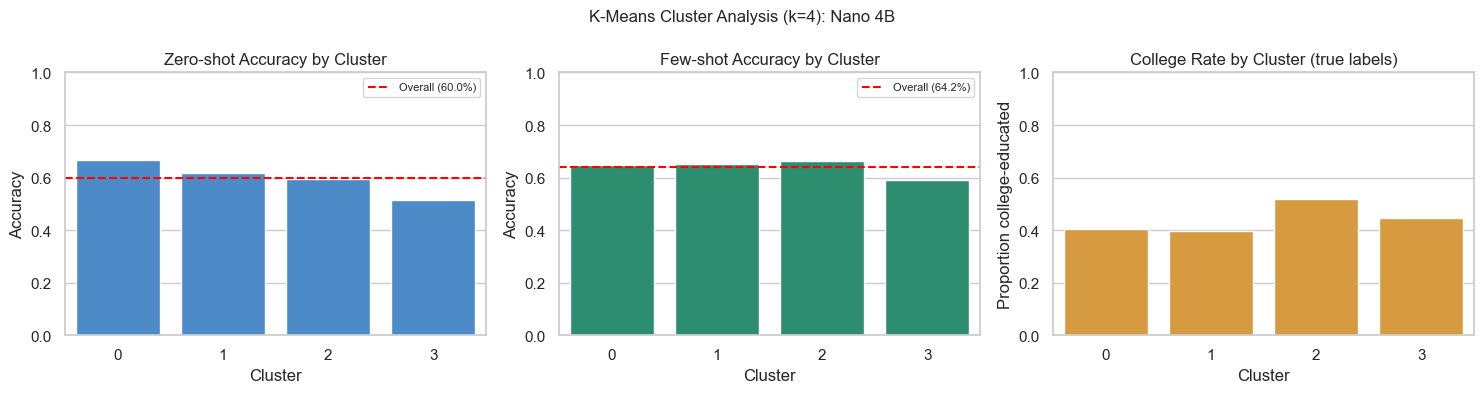

Saved: results/week3_cluster_accuracy.png


In [18]:
# Run K-means with chosen k
# Change K based on what the elbow plot suggests
K = 4

km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels_arr = km.fit_predict(X_scaled)

# Add cluster labels to zero-shot and few-shot results
zs_clustered = zs_df.copy()
fs_clustered = fs_df.copy()
zs_clustered['cluster'] = cluster_labels_arr
fs_clustered['cluster'] = cluster_labels_arr

# Accuracy per cluster
cluster_stats = []

for c in range(K):
    zs_rows = zs_clustered[zs_clustered['cluster'] == c]
    fs_rows = fs_clustered[fs_clustered['cluster'] == c]

    zs_acc = zs_rows['correct'].mean()
    fs_acc = fs_rows['correct'].mean()
    size   = len(zs_rows)
    college_rate = (zs_rows['true_label'] == 'college').mean()

    # Top occupations in this cluster
    top_occ = sample.iloc[zs_rows.index]['occupation'].value_counts().head(3).index.tolist()
    avg_age = sample.iloc[zs_rows.index]['age'].mean()

    cluster_stats.append({
        'cluster':         c,
        'size':            size,
        'zs_accuracy':     round(zs_acc, 3),
        'fs_accuracy':     round(fs_acc, 3),
        'college_rate':    round(college_rate, 3),
        'avg_age':         round(avg_age, 1),
        'top_occupations': ', '.join(top_occ),
    })

    print(f'\n── Cluster {c} ──')
    print(f'  Size:              {size} rows')
    print(f'  Zero-shot accuracy: {zs_acc:.1%}')
    print(f'  Few-shot accuracy:  {fs_acc:.1%}')
    print(f'  College rate:      {college_rate:.1%}')
    print(f'  Avg age:           {avg_age:.1f}')
    print(f'  Top occupations:   {", ".join(top_occ)}')

cluster_df = pd.DataFrame(cluster_stats)
cluster_df.to_csv('../results/week3_cluster_analysis.csv', index=False)
print('\nSaved: results/week3_cluster_analysis.csv')

# Visualization 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Zero-shot accuracy by cluster
sns.barplot(data=cluster_df, x='cluster', y='zs_accuracy',
            color='#378ADD', ax=axes[0])
axes[0].axhline(y=zs_df['correct'].mean(), color='red',
                linestyle='--', label=f'Overall ({zs_df["correct"].mean():.1%})')
axes[0].set_title('Zero-shot Accuracy by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)

# Few-shot accuracy by cluster
sns.barplot(data=cluster_df, x='cluster', y='fs_accuracy',
            color='#1D9E75', ax=axes[1])
axes[1].axhline(y=fs_df['correct'].mean(), color='red',
                linestyle='--', label=f'Overall ({fs_df["correct"].mean():.1%})')
axes[1].set_title('Few-shot Accuracy by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

# College rate by cluster
sns.barplot(data=cluster_df, x='cluster', y='college_rate',
            color='#EF9F27', ax=axes[2])
axes[2].set_title('College Rate by Cluster (true labels)')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Proportion college-educated')
axes[2].set_ylim(0, 1)

plt.suptitle(f'K-Means Cluster Analysis (k={K}): Nano 4B', fontsize=12)
plt.tight_layout()
plt.savefig('../results/week3_cluster_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/week3_cluster_accuracy.png')


## 16. Week 3 Summary

Fill in after running all cells:

| Model | Accuracy | Macro F1 | AUC-ROC | Time/row |
|---|---|---|---|---|
| Random Forest (Week 1) | 83.70% | 0.8366 | 0.9198 | 0.007 ms |
| XGBoost (Week 1) | 76.01% | 0.7598 | 0.8307 | 0.001 ms |
| Nano 4B zero-shot | 58.0% | 0.5711 | 0.5838 | 3,790  ms |
| Nano 4B few-shot | 73.69% | 0.7363 | 0.7362 | 7,052  ms |

**Observations:**
- Few-shot improved accuracy by +15.7 points over zero-shot (58.0% → 73.69%)
- Nano 4B few-shot (73.69%) is within 10 points of Random Forest (83.70%) 
  with zero task-specific training — noise-adjusted gap closes to 6.8 points (76.94% vs 83.70%)
- 23 potential label noise rows identified where Nemotron predicted college 
  for occupations that require degrees (teachers, engineers, accountants) 
  but the synthetic dataset labeled them not_college
- Reasoning traces not available via Ollama OpenAI-compatible API — 
  full chain-of-thought traces will be captured with vLLM on FDS in Week 4
- Few-shot costs 2x more time per row (7,052ms vs 3,790ms) — 
  important accuracy vs speed tradeoff to document


**Next week:** Run same experiments on FDS with Nano 30B FP8 via vLLM but add reasoning ON vs OFF comparison also KN.